In [128]:
import numpy as np
import math as ma
import matplotlib.pyplot as plt
from scipy.special import eval_hermite
import scipy.constants as cnst

In [129]:
eV = cnst.eV
h_c = cnst.hbar
m_e = cnst.m_e
L = 1e-9
ω = 1e15

In [130]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [131]:
import sys

sys.path.append('/content/drive/MyDrive/Colab Notebooks')
from fdm_solver import fdm_schrodinger
from qm_shooting import Find_eigenvalue
from qm_shooting import wave_shooting

**DOUBLE WELL SPLITTING**

1. Finite Difference Method Solver

In [132]:
def double_well_potential(x, params):
    barrier_width = params.get('barrier_width', 0.2) * 1e-9 # Converted to meters
    barrier_height_eV = params.get('barrier_height_eV', 5.0)
    barrier_height_J = barrier_height_eV * cnst.eV

    V = np.where(np.abs(x) < (barrier_width / 2.0), barrier_height_J, 0.0)
    return V

# Parameters
params = {'barrier_width': 0.2, 'barrier_height_eV': 3.0}

--- Double-Well Energy Splitting ---
E0 (Symmetric):      0.3333 eV
E1 (Antisymmetric):  0.3911 eV
Splitting Gap (ΔE):  0.0579 eV


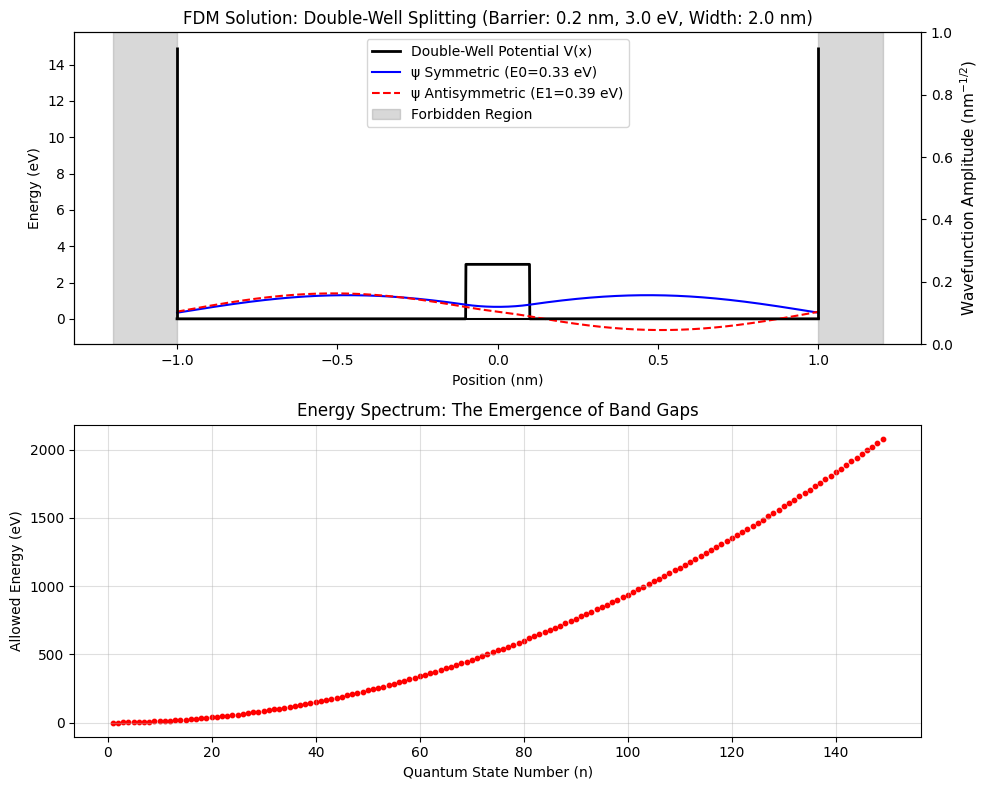

In [133]:
x_start = -1.0 # nm
x_end = 1.0    # nm
N_steps = 2000

Energy, ψ, x_axis = fdm_schrodinger(x_start, x_end, N_steps, double_well_potential, params)

Energy_eV = Energy
x_axis_nm = x_axis
V_plot = double_well_potential(x_axis_nm * 1e-9, params) / eV

print("--- Double-Well Energy Splitting ---")
print(f"E0 (Symmetric):      {Energy_eV[0]:.4f} eV")
print(f"E1 (Antisymmetric):  {Energy_eV[1]:.4f} eV")
print(f"Splitting Gap (ΔE):  {Energy_eV[1] - Energy_eV[0]:.4f} eV")

Barrier_width = params.get('barrier_width')
Barrier_height = params.get('barrier_height_eV')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(x_axis_nm, V_plot, color='black', linewidth=2, label="Double-Well Potential V(x)")
ax1.plot(x_axis_nm, (ψ[:, 0]) + Energy_eV[0], color='blue', label=f"ψ Symmetric (E0={Energy_eV[0]:.2f} eV)")
ax1.plot(x_axis_nm, (ψ[:, 1]) + Energy_eV[1], color='red', linestyle='--', label=f"ψ Antisymmetric (E1={Energy_eV[1]:.2f} eV)")
ax1.set_title(f'FDM Solution: Double-Well Splitting (Barrier: {Barrier_width} nm, {Barrier_height} eV, Width: {x_end - x_start} nm)')
ax1.set_ylabel("Energy (eV)")
ax1.set_xlabel("Position (nm)")
ax1.hlines(y = 0, xmin= x_start, xmax = x_end, color='black', linestyle='-')
ax1.vlines(x=[x_start, x_end], ymin=0, ymax=15, color='black', linewidth=2)
ax1.axvspan(xmin=x_start - 0.2, xmax=x_start, color='gray', alpha=0.3, label="Forbidden Region")
ax1.axvspan(xmin=x_end, xmax=x_end + 0.2, color='gray', alpha=0.3)
ax1.legend()
ax_wave = ax1.twinx()
ax_wave.set_ylabel(r"Wavefunction Amplitude ($\text{nm}^{-1/2}$)", color='black', fontsize=11)

n_states = np.arange(1, 150)
ax2.scatter(n_states, Energy_eV[:149], s=10, color='red')
ax2.set_title("Energy Spectrum: The Emergence of Band Gaps")
ax2.set_xlabel("Quantum State Number (n)")
ax2.set_ylabel("Allowed Energy (eV)")
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Slider for double potential splitting

In [134]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import scipy.constants as cnst
from ipywidgets import interact, FloatSlider

hbar = cnst.hbar
m_e = cnst.m_e
eV = cnst.eV

def solve_double_well(well_width, barrier_width, barrier_height_eV, mass_relative):
    L = 2.0 * well_width + barrier_width + 2.0
    N = 1000
    x = np.linspace(-L/2, L/2, N)
    dx = x[1] - x[0]

    V = np.zeros(N)
    barrier_mask = (x >= -barrier_width/2) & (x <= barrier_width/2)
    V[barrier_mask] = barrier_height_eV * eV
    wall_mask = (x <= -(well_width + barrier_width/2)) | (x >= (well_width + barrier_width/2))
    V[wall_mask] = 1000.0 * eV

    dx_m = dx * 1e-9
    t = (hbar**2) / (2 * (mass_relative * m_e) * dx_m**2)

    diagonal = 2 * t + V
    off_diagonal = -t * np.ones(N - 1)

    energies, wavefunctions = la.eigh_tridiagonal(diagonal, off_diagonal)
    energies_eV = energies / eV

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, V / eV, color='black', lw=2, label='Potential V(x)')

    colors = ['blue', 'red']
    for n in range(2):
        psi = wavefunctions[:, n]
        psi_normalized = psi / np.max(np.abs(psi)) * 0.5
        ax.plot(x, psi_normalized + energies_eV[n], color=colors[n],
                label=f'State E_{n+1} = {energies_eV[n]:.4f} eV')
        ax.axhline(energies_eV[n], color=colors[n], linestyle='--', alpha=0.5)

    splitting = energies_eV[1] - energies_eV[0]

    ax.set_title(f'Double Well Energy Splitting (FDM)\nSplitting $\\Delta E$ = {splitting:.4e} eV', fontsize=12)
    ax.set_xlabel('Position (nm)')
    ax.set_ylabel('Energy (eV)')
    ax.set_ylim(-0.5, barrier_height_eV + 1.5)
    ax.set_xlim(-(well_width + barrier_width/2 + 0.5), (well_width + barrier_width/2 + 0.5))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.show()

interact(
    solve_double_well,
    well_width=FloatSlider(min=0.1, max=2.0, step=0.05, value=0.5, description='Well Width (nm)'),
    barrier_width=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description='Barrier Width (nm)'),
    barrier_height_eV=FloatSlider(min=0.1, max=10.0, step=0.1, value=4.0, description='Barrier Height (eV)'),
    mass_relative=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='Mass (m_e)')
);

interactive(children=(FloatSlider(value=0.5, description='Well Width (nm)', max=2.0, min=0.1, step=0.05), Floa…

2. Shooting Method Solver

In [135]:
def double_well_potential_2(x_nm, params):
    x_m = x_nm * 1e-9
    barrier_width_m = params.get('barrier_width', 0.2) * 1e-9
    barrier_height_eV = params.get('barrier_height_eV', 5.0)
    V_eV = np.where(np.abs(x_m) < (barrier_width_m / 2.0), barrier_height_eV, 0.0)
    return V_eV


params = {'barrier_width': 0.2, 'barrier_height_eV': 3.0}


--- Double-Well Energy Splitting (Shooting Method) ---
E0 (Symmetric):      0.3339 eV
E1 (Antisymmetric):  0.3913 eV
Splitting Gap (ΔE):  0.0575 eV


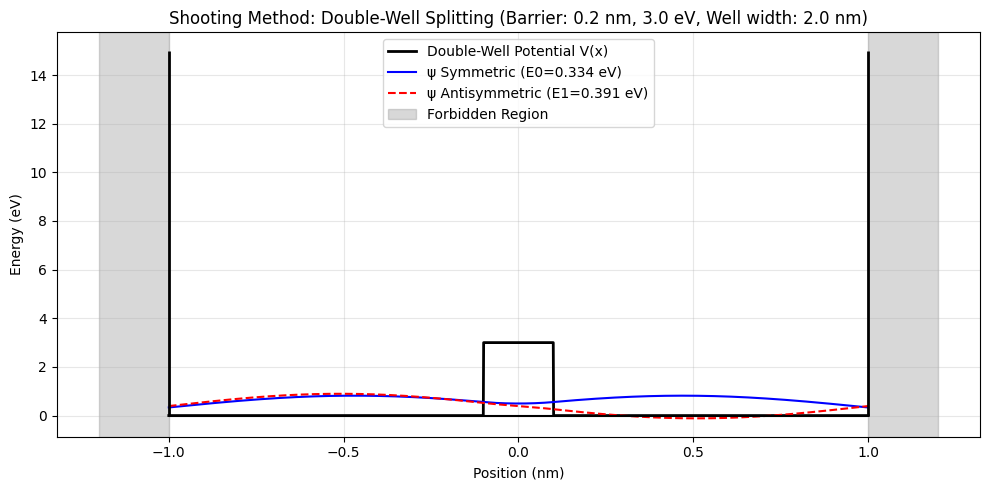

In [136]:
x_start = -1.0   # nm
x_end = 1.0      # nm
N_steps = 2000

soln = wave_shooting(params, double_well_potential_2, x_s=x_start, x_e=x_end,
                      N=N_steps, E_1=0.05, dE=0.05)

Energy = np.array([soln["Ground State"]["E"], soln["Excited State 1"]["E"]])
psi = np.array([soln["Ground State"]["Pi"], soln["Excited State 1"]["Pi"]])
x_axis = np.array(soln["Ground State"]["x"])   # already in nm

Energy_eV = Energy
V_plot = double_well_potential_2(x_axis, params)   # nm-based function on nm-based axis
x_axis_nm = x_axis   # already nm, no further rescaling

print("--- Double-Well Energy Splitting (Shooting Method) ---")
print(f"E0 (Symmetric):      {Energy_eV[0]:.4f} eV")
print(f"E1 (Antisymmetric):  {Energy_eV[1]:.4f} eV")
print(f"Splitting Gap (\u0394E):  {Energy_eV[1] - Energy_eV[0]:.4f} eV")

Barrier_width = params.get('barrier_width')
Barrier_height = params.get('barrier_height_eV')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(x_axis_nm, V_plot, color='black', linewidth=2, label="Double-Well Potential V(x)")
ax1.plot(x_axis_nm, psi[0] * 0.5 + Energy_eV[0], color='blue',
         label=f"\u03c8 Symmetric (E0={Energy_eV[0]:.3f} eV)")
ax1.plot(x_axis_nm, psi[1] * 0.5 + Energy_eV[1], color='red', linestyle='--',
         label=f"\u03c8 Antisymmetric (E1={Energy_eV[1]:.3f} eV)")
ax1.set_title(f'Shooting Method: Double-Well Splitting '
              f'(Barrier: {Barrier_width} nm, {Barrier_height} eV, '
              f'Well width: {x_end - x_start} nm)')
ax1.set_ylabel("Energy (eV)")
ax1.set_xlabel("Position (nm)")
ax1.hlines(y = 0, xmin= x_start, xmax = x_end, color='black', linestyle='-')
ax1.vlines(x=[x_start, x_end], ymin=0, ymax=15, color='black', linewidth=2)
ax1.axvspan(xmin=x_start - 0.2, xmax=x_start, color='gray', alpha=0.3, label="Forbidden Region")
ax1.axvspan(xmin=x_end, xmax=x_end + 0.2, color='gray', alpha=0.3)
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Slider for double potential splitting

In [137]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cnst
from ipywidgets import interact, FloatSlider
from scipy.optimize import brentq

h_c = cnst.hbar
m_e = cnst.m_e
eV = cnst.eV

fig_dw, (ax1_dw, ax2_dw) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
plt.close(fig_dw)

def integrate_dw_shooting(E_eV, well_width, barrier_width, barrier_height_eV, mass_relative, parity):
    N_half = 500
    L_half = well_width + barrier_width / 2.0
    x_half = np.linspace(0, L_half, N_half)
    dx = x_half[1] - x_half[0]

    m = mass_relative * m_e
    E = E_eV * eV

    V_half = np.zeros(N_half)
    barrier_mask = x_half <= (barrier_width / 2.0)
    V_half[barrier_mask] = barrier_height_eV * eV

    psi_half = np.zeros(N_half)
    dx_m = dx * 1e-9

    if parity == 'even':
        psi_half[0] = 1.0
        psi_half[1] = psi_half[0] - 0.5 * (dx_m**2) * (2 * m / h_c**2) * (E - V_half[0]) * psi_half[0]
    else:
        psi_half[0] = 0.0
        psi_half[1] = dx_m

    for i in range(1, N_half - 1):
        k2 = (2 * m / h_c**2) * (E - V_half[i])
        psi_half[i+1] = 2 * psi_half[i] - psi_half[i-1] - (dx_m**2) * k2 * psi_half[i]

    if parity == 'even':
        x_full = np.concatenate([-x_half[::-1][:-1], x_half])
        psi_full = np.concatenate([psi_half[::-1][:-1], psi_half])
    else:
        x_full = np.concatenate([-x_half[::-1][:-1], x_half])
        psi_full = np.concatenate([-psi_half[::-1][:-1], psi_half])

    return psi_half[-1], x_full, psi_full

def find_dw_numerical_states(well_width, barrier_width, barrier_height_eV, mass_relative):
    E_search = np.logspace(-4, np.log10(barrier_height_eV - 1e-4), 300)
    bound_states = []

    for parity in ['even', 'odd']:
        res = []
        for E in E_search:
            residual, _, _ = integrate_dw_shooting(E, well_width, barrier_width, barrier_height_eV, mass_relative, parity)
            res.append(residual)

        res = np.array(res)
        signs = np.sign(res)
        sign_changes = np.where(signs[:-1] != signs[1:])[0]

        for idx in sign_changes:
            if abs(res[idx] - res[idx+1]) < 1e5:
                try:
                    def local_residual(E_val):
                        val, _, _ = integrate_dw_shooting(E_val, well_width, barrier_width, barrier_height_eV, mass_relative, parity)
                        return val
                    E_root = brentq(local_residual, E_search[idx], E_search[idx+1], xtol=1e-9)
                    bound_states.append((E_root, parity))
                except ValueError:
                    pass

    bound_states = sorted(bound_states, key=lambda x: x[0])
    return bound_states[:2]

def solve_double_well_shooting_notebook(well_width, barrier_width, barrier_height_eV, mass_relative):
    states = find_dw_numerical_states(well_width, barrier_width, barrier_height_eV, mass_relative)

    ax1_dw.clear()
    ax2_dw.clear()

    total_span = well_width + barrier_width / 2.0 + 0.5
    x_pot = np.linspace(-total_span, total_span, 1000)
    V_pot = np.zeros_like(x_pot)
    V_pot[(x_pot >= -barrier_width/2) & (x_pot <= barrier_width/2)] = barrier_height_eV

    ax1_dw.plot(x_pot, V_pot, color='black', lw=2, label="Potential V(x)")
    ax2_dw.plot(x_pot, V_pot, color='black', lw=2, label="Potential V(x)")

    if len(states) >= 2:
        splitting = states[1][0] - states[0][0]
        ax1_dw.set_title(f"Double Well Energy Splitting - Barrier width: {barrier_width} nm, Well width = {well_width} nm\nSplitting $\\Delta E$ = {splitting:.4e} eV", fontsize=11)
    else:
        ax1_dw.set_title(f"Double Well Energy Splitting - Barrier width: {barrier_width} nm, Well width = {well_width} nm\nSeeking Symmetric Pairs...", fontsize=11)

    colors = ['blue', 'red']
    for i, (E_level, parity) in enumerate(states):
        ax1_dw.axhline(E_level, color=colors[i], linestyle='--', alpha=0.7, label=f"State {i+1} ({parity}): {E_level:.4f} eV")

        _, x_wf, psi_wf = integrate_dw_shooting(E_level, well_width, barrier_width, barrier_height_eV, mass_relative, parity)
        psi_normalized = psi_wf / np.max(np.abs(psi_wf)) * 0.3

        ax2_dw.plot(x_wf, psi_normalized + E_level, color=colors[i], alpha=0.8, label=f"Wavefunction $\\psi_{i+1}(x)$")
        ax2_dw.axhline(E_level, color=colors[i], linestyle=':', alpha=0.4)

    ax1_dw.set_ylabel("Energy (eV)")
    ax1_dw.legend(loc="upper right")
    ax1_dw.grid(True, alpha=0.3)

    ax2_dw.set_ylabel("Energy (eV)")
    ax2_dw.set_xlabel("Position (nm)")
    ax2_dw.set_xlim(-total_span, total_span)
    ax2_dw.set_ylim(-0.5, barrier_height_eV + 1.5)
    ax2_dw.legend(loc="upper right")
    ax2_dw.grid(True, alpha=0.3)

    display(fig_dw)

interact(
    solve_double_well_shooting_notebook,
    well_width=FloatSlider(min=0.1, max=2.0, step=0.05, value=0.5, description='well_width', continuous_update=False),
    barrier_width=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description='barrier_width', continuous_update=False),
    barrier_height_eV=FloatSlider(min=0.1, max=15.0, step=0.1, value=4.0, description='barrier_height_eV', continuous_update=False),
    mass_relative=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='mass_relative', continuous_update=False)
);

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='well_width', max=2.0, min=0…

**Kronig Penny Model**

1. Finite Difference Method Solver

In [138]:
#Potential
def kronig_penney_potential(x, params):
    well_width = params.get('well_width', 0.4)* 1e-9
    barrier_width = params.get('barrier_width', 0.1)* 1e-9
    barrier_height_eV = params.get('barrier_height_eV', 10.0)

    barrier_height_J = barrier_height_eV * eV
    lattice_constant = well_width + barrier_width

    V = np.where((x % lattice_constant) > well_width, barrier_height_J, 0.0)
    return V

#Parameters
params = {'well_width': 0.4, 'barrier_width': 0.1, 'barrier_height_eV': 10.0}

---Energy Levels ---
State n=1: 1.102 eV
State n=2: 1.120 eV
State n=3: 1.156 eV


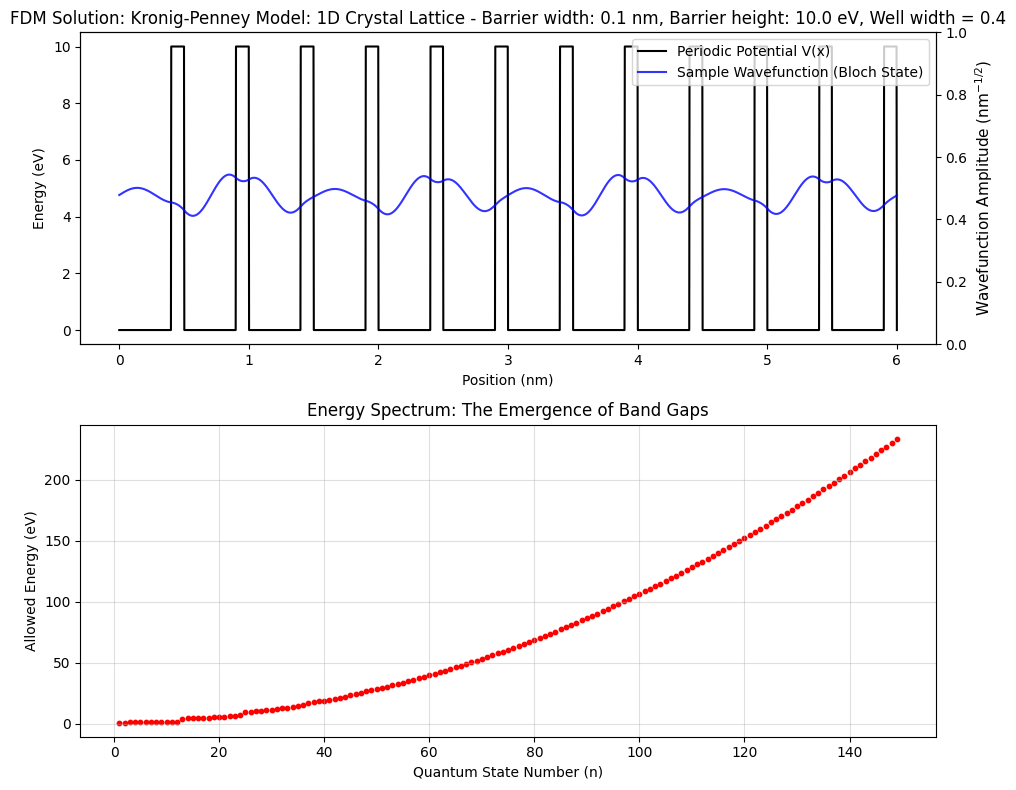

In [139]:
num_cells = 12
lattice_constant = params['well_width'] + params['barrier_width']

x_start = 0.0
x_end = num_cells * lattice_constant
N = 2500

Energy, ψ, x_axis = fdm_schrodinger(x_start, x_end, N, kronig_penney_potential, params=params)
Energy_eV = Energy


V_plot = kronig_penney_potential(x_axis * 1e-9, params) / eV

Well_width = params.get('well_width')
Barrier_width = params.get('barrier_width')
Barrier_height = params.get('barrier_height_eV')

print("---Energy Levels ---")
for n in range(3):
    print(f"State n={n+1}: {Energy_eV[n]:.3f} eV")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(x_axis, V_plot, color='black', label="Periodic Potential V(x)")
ax1.plot(x_axis, ψ[:, 15] + Energy_eV[15], color='blue', alpha=0.8, label="Sample Wavefunction (Bloch State)")
ax1.set_title(f"FDM Solution: Kronig-Penney Model: 1D Crystal Lattice - Barrier width: {Barrier_width} nm, Barrier height: {Barrier_height} eV, Well width = {Well_width}")
ax1.set_ylabel("Energy (eV)")
ax1.set_xlabel("Position (nm)")
ax1.legend(loc="upper right")
ax_wave = ax1.twinx()
ax_wave.set_ylabel(r"Wavefunction Amplitude ($\text{nm}^{-1/2}$)", color='black', fontsize=11)

n_states = np.arange(1, 150)
ax2.scatter(n_states, Energy_eV[:149], s=10, color='red')
ax2.set_title("Energy Spectrum: The Emergence of Band Gaps")
ax2.set_xlabel("Quantum State Number (n)")
ax2.set_ylabel("Allowed Energy (eV)")
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Slider for kronig penny model

In [140]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import scipy.constants as cnst
from ipywidgets import interact, FloatSlider

# Using variables defined in your notebook
h_c = cnst.hbar
m_e = cnst.m_e
eV = cnst.eV

fig_fdm, (ax1_fdm, ax2_fdm) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
plt.close(fig_fdm)

def solve_kronig_penney_fdm_notebook(well_width, barrier_width, barrier_height_eV, mass_relative):
    a = well_width
    b = barrier_width
    L_period = a + b
    N = 300
    x_axis = np.linspace(0, L_period, N, endpoint=False)
    dx = x_axis[1] - x_axis[0]

    V_plot = np.zeros(N)
    barrier_mask = x_axis >= a
    V_plot[barrier_mask] = barrier_height_eV * eV

    dx_m = dx * 1e-9
    t = (h_c**2) / (2 * (mass_relative * m_e) * dx_m**2)

    diagonal = 2 * t + V_plot
    off_diagonal = -t * np.ones(N - 1)

    H = np.diag(diagonal) + np.diag(off_diagonal, 1) + np.diag(off_diagonal, -1)
    H[0, -1] = -t
    H[-1, 0] = -t

    Energy, psi = la.eigh(H)
    Energy_eV = Energy / eV

    ax1_fdm.clear()
    ax2_fdm.clear()

    x_extended = np.linspace(-L_period, 2 * L_period, 1000)
    V_extended = np.zeros_like(x_extended)
    for period in [-1, 0, 1]:
        shift = period * L_period
        mask = (x_extended >= shift + a) & (x_extended < shift + L_period)
        V_extended[mask] = barrier_height_eV

    ax1_fdm.plot(x_extended, V_extended, color='black', lw=2, label="Periodic Potential V(x)")
    ax2_fdm.plot(x_extended, V_extended, color='black', lw=2, label="Periodic Potential V(x)")

    colors = ['blue', 'red', 'green']
    for n in range(min(3, N)):
        E_level = Energy_eV[n]
        ax1_fdm.axhline(E_level, color=colors[n], linestyle='--', alpha=0.7, label=f"State n={n+1}: {E_level:.3f} eV")

        psi_cell = psi[:, n]
        psi_periodic = np.tile(psi_cell, 3)
        x_periodic = np.linspace(-L_period, 2 * L_period, 3 * N, endpoint=False)
        psi_normalized = psi_periodic / np.max(np.abs(psi_periodic)) * 0.3

        ax2_fdm.plot(x_periodic, psi_normalized + E_level, color=colors[n], alpha=0.8, label=f"Wavefunction (state {n+1})")
        ax2_fdm.axhline(E_level, color=colors[n], linestyle=':', alpha=0.4)

    ax1_fdm.set_title(f"FDM: Kronig-Penney Model - Barrier width: {barrier_width} nm, Barrier height: {barrier_height_eV} eV, Well width = {well_width} nm")
    ax1_fdm.set_ylabel("Energy (eV)")
    ax1_fdm.legend(loc="upper right")
    ax1_fdm.grid(True, alpha=0.3)

    ax2_fdm.set_ylabel("Energy (eV)")
    ax2_fdm.set_xlabel("Position (nm)")
    ax2_fdm.set_xlim(-0.5 * L_period, 1.5 * L_period)
    ax2_fdm.set_ylim(-0.5, barrier_height_eV + 2.0)
    ax2_fdm.legend(loc="upper right")
    ax2_fdm.grid(True, alpha=0.3)

    display(fig_fdm)

interact(
    solve_kronig_penney_fdm_notebook,
    well_width=FloatSlider(min=0.1, max=2.0, step=0.05, value=0.5, description='well_width', continuous_update=False),
    barrier_width=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description='barrier_width', continuous_update=False),
    barrier_height_eV=FloatSlider(min=0.1, max=15.0, step=0.1, value=5.0, description='barrier_height_eV', continuous_update=False),
    mass_relative=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='mass_relative', continuous_update=False)
);

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='well_width', max=2.0, min=0…

Shooting method: Kronig Penny

Solving for 60 states via shooting method (domain 0 to 6.0 nm, this will take a few minutes)...
  state 0: E = 1.1014 eV   (elapsed 6.8s)
  state 10: E = 1.6004 eV   (elapsed 15.3s)
  state 20: E = 5.9939 eV   (elapsed 48.3s)
  state 30: E = 12.1764 eV   (elapsed 93.8s)
  state 40: E = 19.8935 eV   (elapsed 153.0s)
  state 50: E = 29.4281 eV   (elapsed 232.7s)

--- Energy Levels (Shooting Method) ---
State n=1: 1.101 eV
State n=2: 1.121 eV
State n=3: 1.154 eV


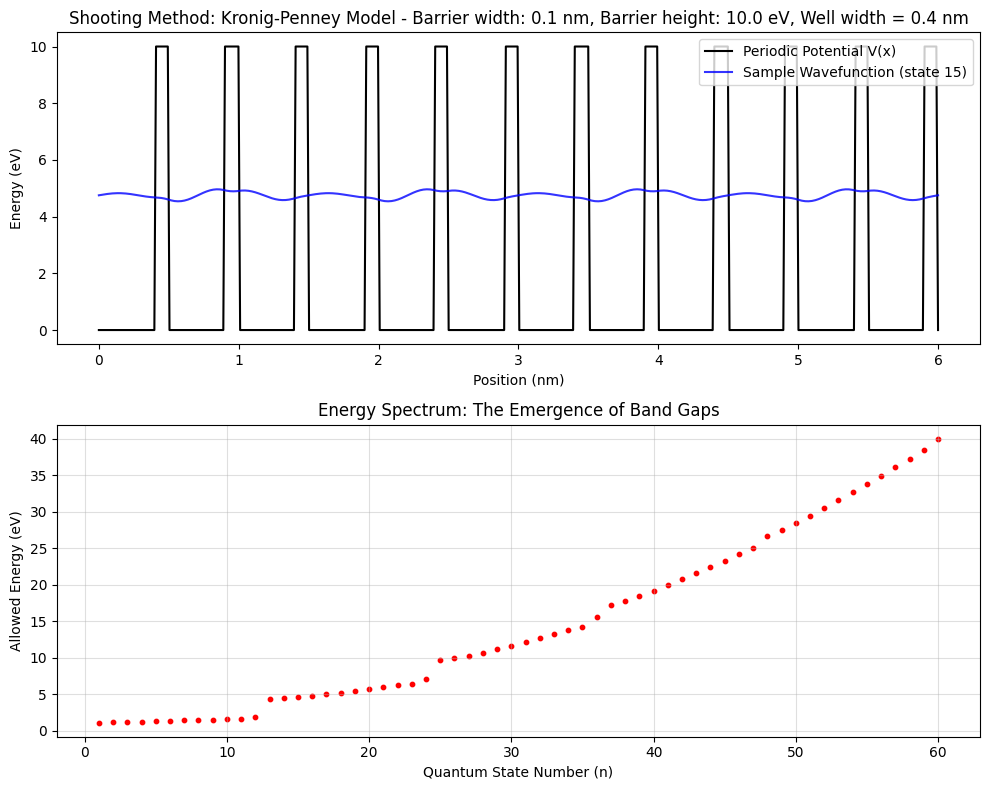

In [141]:
import time
from qm_shooting import Find_eigenvalue   # adjust import path as in your notebook

def kronig_penney_potential_2(x_nm, params):

    well_width_nm = params.get('well_width', 0.4)
    barrier_width_nm = params.get('barrier_width', 0.1)
    barrier_height_eV = params.get('barrier_height_eV', 10.0)
    lattice_constant_nm = well_width_nm + barrier_width_nm

    x_mod = np.mod(x_nm, lattice_constant_nm)
    V_eV = np.where(x_mod > well_width_nm, barrier_height_eV, 0.0)
    return V_eV


def kp_shooting_spectrum(params, n_states, x_start, x_end, N=500,
                          E_1=0.01, dE=0.01, rtol=1e-6, verbose=True):

    energies = []
    psis = []
    x_axis = None
    t0 = time.time()
    for i in range(n_states):
        x_list, Pi, E = Find_eigenvalue(params, kronig_penney_potential_2,
                                         x_s=x_start, x_e=x_end, N=N,
                                         E_1=E_1, dE=dE, rtol=rtol)
        energies.append(E)
        psis.append(Pi)
        if x_axis is None:
            x_axis = x_list
        E_1 = E + dE
        if verbose and i % 10 == 0:
            print(f"  state {i}: E = {E:.4f} eV   (elapsed {time.time()-t0:.1f}s)")
    return np.array(energies), np.array(psis), x_axis


params = {'well_width': 0.4, 'barrier_width': 0.1, 'barrier_height_eV': 10.0}

num_cells = 12
lattice_constant = params['well_width'] + params['barrier_width']

x_start = 0.0
x_end = num_cells * lattice_constant   # nm
N_steps = 500

N_STATES = 60

print(f"Solving for {N_STATES} states via shooting method "
      f"(domain 0 to {x_end:.1f} nm, this will take a few minutes)...")
Energy, psi, x_axis = kp_shooting_spectrum(params, N_STATES, x_start, x_end, N=N_steps)
Energy_eV = Energy

V_plot = kronig_penney_potential_2(x_axis, params)

Well_width = params.get('well_width')
Barrier_width = params.get('barrier_width')
Barrier_height = params.get('barrier_height_eV')

print("\n--- Energy Levels (Shooting Method) ---")
for n in range(min(3, N_STATES)):
    print(f"State n={n+1}: {Energy_eV[n]:.3f} eV")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

sample_state = min(15, N_STATES - 1)
ax1.plot(x_axis, V_plot, color='black', label="Periodic Potential V(x)")
ax1.plot(x_axis, psi[sample_state] * 0.3 + Energy_eV[sample_state], color='blue', alpha=0.8,
          label=f"Sample Wavefunction (state {sample_state})")
ax1.set_title(f"Shooting Method: Kronig-Penney Model - Barrier width: {Barrier_width} nm, "
              f"Barrier height: {Barrier_height} eV, Well width = {Well_width} nm")
ax1.set_ylabel("Energy (eV)")
ax1.set_xlabel("Position (nm)")
ax1.legend(loc="upper right")

n_states_axis = np.arange(1, N_STATES + 1)
ax2.scatter(n_states_axis, Energy_eV, s=10, color='red')
ax2.set_title("Energy Spectrum: The Emergence of Band Gaps")
ax2.set_xlabel("Quantum State Number (n)")
ax2.set_ylabel("Allowed Energy (eV)")
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Slider for kronig penny model

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cnst
from ipywidgets import interact, FloatSlider
from scipy.optimize import brentq

h_c = cnst.hbar
m_e = cnst.m_e
eV = cnst.eV

fig_shoot, (ax1_shoot, ax2_shoot) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
plt.close(fig_shoot)

def integrate_kp_shooting(E_eV, well_width, barrier_width, barrier_height_eV, mass_relative):
    # Numerical integration across one full unit cell period [0, a+b]
    N_cell = 400
    L_period = well_width + barrier_width
    x_cell = np.linspace(0, L_period, N_cell)
    dx = x_cell[1] - x_cell[0]

    m = mass_relative * m_e
    E = E_eV * eV

    V = np.zeros(N_cell)
    barrier_mask = x_cell >= well_width
    V[barrier_mask] = barrier_height_eV * eV

    psi = np.zeros(N_cell)
    # Periodic boundary conditions boundary setup: psi(0) = 1, psi'(0) = 0 for band edges at k=0
    psi[0] = 1.0
    dx_m = dx * 1e-9
    psi[1] = psi[0] - 0.5 * (dx_m**2) * (2 * m / h_c**2) * (E - V[0]) * psi[0]

    for i in range(1, N_cell - 1):
        k2 = (2 * m / h_c**2) * (E - V[i])
        psi[i+1] = 2 * psi[i] - psi[i-1] - (dx_m**2) * k2 * psi[i]

    # Periodic boundary matching constraint boundary check: psi(L) - psi(0) should equal 0
    return psi[-1] - psi[0], x_cell, psi

def find_kp_numerical_states(well_width, barrier_width, barrier_height_eV, mass_relative):
    E_search = np.logspace(-4, np.log10(barrier_height_eV + 8.0), 300)
    bound_states = []

    res = []
    for E in E_search:
        residual, _, _ = integrate_kp_shooting(E, well_width, barrier_width, barrier_height_eV, mass_relative)
        res.append(residual)

    res = np.array(res)
    signs = np.sign(res)
    sign_changes = np.where(signs[:-1] != signs[1:])[0]

    for idx in sign_changes:
        if abs(res[idx] - res[idx+1]) < 50.0:
            try:
                def local_residual(E_val):
                    val, _, _ = integrate_kp_shooting(E_val, well_width, barrier_width, barrier_height_eV, mass_relative)
                    return val
                E_root = brentq(local_residual, E_search[idx], E_search[idx+1], xtol=1e-8)
                bound_states.append(E_root)
            except ValueError:
                pass

    return sorted(list(set(np.round(bound_states, 4))))[:3]

def solve_kronig_penney_shooting_notebook(well_width, barrier_width, barrier_height_eV, mass_relative):
    Energy_eV = find_kp_numerical_states(well_width, barrier_width, barrier_height_eV, mass_relative)

    ax1_shoot.clear()
    ax2_shoot.clear()
    L_period = well_width + barrier_width

    x_extended = np.linspace(-L_period, 2 * L_period, 1000)
    V_extended = np.zeros_like(x_extended)
    for period in [-1, 0, 1]:
        shift = period * L_period
        mask = (x_extended >= shift + well_width) & (x_extended < shift + L_period)
        V_extended[mask] = barrier_height_eV

    ax1_shoot.plot(x_extended, V_extended, color='black', label="Periodic Potential V(x)")
    ax2_shoot.plot(x_extended, V_extended, color='black', label="Periodic Potential V(x)")

    colors = ['blue', 'red', 'green']
    for i, E_level in enumerate(Energy_eV):
        ax1_shoot.axhline(E_level, color=colors[i], linestyle='--', alpha=0.7, label=f"State n={i+1}: {E_level:.3f} eV")

        _, x_cell, psi_cell = integrate_kp_shooting(E_level, well_width, barrier_width, barrier_height_eV, mass_relative)
        psi_periodic = np.tile(psi_cell, 3)
        x_periodic = np.linspace(-L_period, 2 * L_period, len(psi_periodic))
        psi_normalized = psi_periodic / np.max(np.abs(psi_periodic)) * 0.3

        ax2_shoot.plot(x_periodic, psi_normalized + E_level, color=colors[i], alpha=0.8, label=f"Wavefunction (state {i+1})")
        ax2_shoot.axhline(E_level, color=colors[i], linestyle=':', alpha=0.4)

    ax1_shoot.set_title(f"Shooting Method: Kronig-Penney Model - Barrier width: {barrier_width} nm, Barrier height: {barrier_height_eV} eV, Well width = {well_width} nm")
    ax1_shoot.set_ylabel("Energy (eV)")
    ax1_shoot.legend(loc="upper right")
    ax1_shoot.grid(True, alpha=0.3)

    ax2_shoot.set_ylabel("Energy (eV)")
    ax2_shoot.set_xlabel("Position (nm)")
    ax2_shoot.set_xlim(-0.5 * L_period, 1.5 * L_period)
    ax2_shoot.set_ylim(-0.5, barrier_height_eV + 4.0)
    ax2_shoot.legend(loc="upper right")
    ax2_shoot.grid(True, alpha=0.3)

    display(fig_shoot)

interact(
    solve_kronig_penney_shooting_notebook,
    well_width=FloatSlider(min=0.1, max=2.0, step=0.05, value=0.5, description='well_width', continuous_update=False),
    barrier_width=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description='barrier_width', continuous_update=False),
    barrier_height_eV=FloatSlider(min=0.1, max=15.0, step=0.1, value=5.0, description='barrier_height_eV', continuous_update=False),
    mass_relative=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='mass_relative', continuous_update=False)
);

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='well_width', max=2.0, min=0…